In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
# from matplotlib.cm import get_cmap

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [30]:
def import_data(mode:list , num_policy:int , case:str, level:int=5):
    dataset = {key : [] for key in mode}
    for i in dataset.keys():   # sensor modality
        for policy in range(num_policy): # each run have 3 policies
            if case == "slope":
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npz" , allow_pickle=True))

            else:
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npz" , allow_pickle=True))

    # print(dataset)
    for key, value in dataset.items():
        dataset[key] = np.array(value)
    return dataset

In [31]:
NUM_POLICY = 5
# Hebb vs CPG
mode = ["pos_action", "vel", "vel_action" ,"pos_vel_action"]

flat        =   import_data(mode , NUM_POLICY , case="flat")
slope_10    =   import_data(mode , NUM_POLICY , case="slope",level=-10)
slope10     =   import_data(mode , NUM_POLICY , case="slope",level=10)

mass1000    =   import_data(mode , NUM_POLICY , case="mass" , level=1000)


# flat        =   import_data(mode , NUM_POLICY , case="flat")
rough       =   import_data(mode , NUM_POLICY , case="rough")
morph       =   import_data(mode , NUM_POLICY , case="morph")

slope_list      = [slope10 ,slope_10 ] # The 15 is slip so the result is shown in not significant way. [slope5 , slope10 , slope15 , slope_5 , slope_10 ,  slope_15]
slope_list_str  = ["slope10" , "slope_10"]


mass_list       = [mass1000] # [mass250 , mass500 , mass1000 , mass2000 , mass5000 , mass10000
mass_list_str   = ["mass1000"]
# [case:str][number_file:int][data/brain:str]

## Preprocess Data

In [32]:
def preprocess(selected_dataset , num_pol):
    performance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    max_distance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    avg_vel = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}

    for policy in range(num_pol):
        for case in selected_dataset.keys():
            reward = np.sum(selected_dataset[case][policy]["data"]['reward'], axis=0)
            performance[f"policy{policy}"][case] = reward

            max_pos_x = np.max(selected_dataset[case][policy]["data"]['pos_x'], axis=0)
            max_distance[f"policy{policy}"][case] = max_pos_x

            vel_x = selected_dataset[case][policy]["data"]['vel_b'][:,:,0]
            avg_vel[f"policy{policy}"][case] = np.mean(vel_x ,axis=0)
    return performance , max_distance , avg_vel

def preprocess_combined(selected_dataset, num_pol):
    """
    Combine values from ALL policies into one 'policy_all' per case.

    Returns:
        performance_all, max_distance_all, avg_vel_all
        # Each is a dict like:
        # {
        #   'policy_all': {
        #       <case_a>: np.ndarray(... concatenated from all policies ...),
        #       <case_b>: np.ndarray(...),
        #       ...
        #   }
        # }
    """
    cases = list(selected_dataset.keys())

    # Buckets (lists) to collect per-policy arrays before concatenating
    perf_bucket = {case: [] for case in cases}
    dist_bucket = {case: [] for case in cases}
    vel_bucket  = {case: [] for case in cases}

    for policy in range(num_pol):
        for case in cases:
            # data = selected_dataset[case][policy]["data"]
            data = selected_dataset[case][policy]
            # print(case , data.keys())
            # 1) reward sum over time -> shape (..., ?) then flatten along new axis 0
            # print(data.keys())
            reward = np.sum(data["reward"], axis=0)
            perf_bucket[case].append(np.ravel(reward))

            # 2) max pos_x over time
            max_pos_x = np.max(data["pos_x"], axis=0)
            dist_bucket[case].append(np.ravel(max_pos_x))

            # 3) avg vel_x over time (take x component from vel_b[..., 0])
            vel_x = data["vel_b"][:, :, 0]
            avg_vel_x = np.mean(vel_x, axis=0)
            vel_bucket[case].append(np.ravel(avg_vel_x))

    # Concatenate across all policies so each case has one long vector
    performance_all = {"policy": {case: np.concatenate(perf_bucket[case], axis=0) if len(perf_bucket[case]) else np.array([]) for case in cases}}
    max_distance_all = {"policy": {case: np.concatenate(dist_bucket[case], axis=0) if len(dist_bucket[case]) else np.array([]) for case in cases}}
    avg_vel_all = {"policy": {case: np.concatenate(vel_bucket[case], axis=0) if len(vel_bucket[case]) else np.array([]) for case in cases}}

    return performance_all, max_distance_all, avg_vel_all

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb


def _pastel_colors(n):
    """Generate n pastel-ish colors by blending tab10 with white."""
    base = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    ]
    blend = []
    for i in range(n):
        r, g, b = to_rgb(base[i % len(base)])
        blend.append((0.7 + 0.3 * r, 0.7 + 0.3 * g, 0.7 + 0.3 * b))
    return blend


def plot_case_violinplot(
    metric_all: dict,
    policy_key: str = "policy",
    title: str = "Distribution by Case",
    ylabel: str = "",
    ylim: list = [0, 5],
    rotate_xticks: int = 30,
    savepath: str | None = None,
    show: bool = True,
    # --- pastel bodies ---
    pastel: bool = True,
    pastel_alpha: float = 0.9,
    # --- jittered points ---
    show_points: bool = True,
    jitter: float = 0.08,
    point_size: float = 8,
    point_alpha: float = 0.6,
    rng_seed: int | None = None,
):
    """
    Plot one pastel-filled violin per case and overlay jittered points.

    Parameters
    ----------
    metric_all : dict
        { policy_key: { case_name: np.ndarray, ... } }
    policy_key : str
        Which top-level key to use from metric_all.

    Returns
    -------
    (fig, ax)
    """
    if policy_key not in metric_all:
        raise KeyError(
            f"Expected key '{policy_key}' in metric_all. "
            f"Got keys: {list(metric_all.keys())}"
        )

    case_map = metric_all[policy_key]
    cases, data = [], []
    for case, arr in case_map.items():
        arr = np.asarray(arr)
        if arr.size == 0:
            continue
        cases.append(case)
        data.append(arr)

    if len(data) == 0:
        raise ValueError("No non-empty case arrays found to plot.")

    rng = np.random.default_rng(rng_seed)
    colors = _pastel_colors(len(data))
    fig, ax = plt.subplots(figsize=(10, 5))

    bp = ax.violinplot(
        data,
        showmeans=True,
        showmedians=True,
    )

    # Pastel fill — violinplot returns bp["bodies"], not bp["boxes"]
    if pastel:
        for body, c in zip(bp["bodies"], colors):
            body.set_facecolor(c)
            body.set_edgecolor("black")
            body.set_alpha(pastel_alpha)
            body.set_linewidth(1.0)

    # Style the mean and median lines
    bp["cmeans"].set_color("black")
    bp["cmeans"].set_linewidth(1.4)
    bp["cmedians"].set_color("dimgray")
    bp["cmedians"].set_linewidth(1.0)
    bp["cbars"].set_linewidth(0.8)
    bp["cmins"].set_linewidth(0.8)
    bp["cmaxes"].set_linewidth(0.8)

    # Jittered points overlay
    if show_points:
        clip_half_width = 0.35
        for i, arr in enumerate(data, start=1):
            xj = rng.normal(i, jitter, size=arr.size)
            xj = np.clip(xj, i - clip_half_width, i + clip_half_width)
            c = colors[i - 1] if pastel else None
            # darken the pastel color slightly for the points so they stand out
            if c is not None:
                r, g, b = c
                c = (max(0, r - 0.25), max(0, g - 0.25), max(0, b - 0.25))
            ax.scatter(xj, arr, s=point_size, alpha=point_alpha,
                       color=c, edgecolors="none", zorder=3)

    # Mean / median annotations to the right of each violin
    for i, arr in enumerate(data, start=1):
        mean_val = arr.mean()
        median_val = np.median(arr)
        ax.annotate(f"μ={mean_val:.3f}", xy=(i, mean_val),
                    xytext=(8, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=10,
                    color="black", fontweight="bold")
        ax.annotate(f"m={median_val:.3f}", xy=(i, median_val),
                    xytext=(8, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=10,
                    color="dimgray")

    # x-tick labels (violinplot doesn't accept tick_labels directly)
    ax.set_xticks(range(1, len(cases) + 1))
    ax.set_xticklabels(cases)

    # Axes formatting
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=13)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    if rotate_xticks:
        for tick in ax.get_xticklabels():
            tick.set_rotation(rotate_xticks)
            tick.set_ha("right")

    # Mean annotation just below the top of the plot
    y_max = ax.get_ylim()[1]
    y_range = y_max - ax.get_ylim()[0]
    for i, arr in enumerate(data, start=1):
        ax.text(i, y_max - 0.05 * y_range, f"μ={arr.mean():.3f}",
                ha="center", va="top", fontsize=12)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgb

def _get_academic_palette(n):
    """Returns a desaturated, professional palette suitable for publication."""
    # Using 'deep' or 'muted' is standard for A* papers
    return sns.color_palette("muted", n_colors=n)

def plot_case_violinplot(
    metric_all: dict,
    policy_key: str = "policy",
    title: str = "Distribution by Case",
    ylabel: str = "Metric Value",
    ylim: list = None,
    rotate_xticks: int = 90, #0, # Reduced default rotation for cleaner look
    savepath: str | None = None,
    show: bool = True,
    show_points: bool = True,
    jitter: float = 0.05,
    point_size: float = 4,
    point_alpha: float = 0.5,
    rng_seed: int = 42,
):
    """
    Publication-quality violin plot with jittered points.
    Optimized for A* conferences (NeurIPS, ICML, CVPR style).
    """
    # 1. Set Academic Styling
    sns.set_theme(style="whitegrid", font="serif") 
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "axes.edgecolor": "#333333",
        "grid.alpha": 0.3
    })

    if policy_key not in metric_all:
        raise KeyError(f"Expected '{policy_key}' in metric_all.")

    case_map = metric_all[policy_key]
    cases, data = [], []
    for case, arr in case_map.items():
        arr = np.asarray(arr)
        if arr.size > 0:
            cases.append(case)
            data.append(arr)

    if not data:
        raise ValueError("No data found.")

    rng = np.random.default_rng(rng_seed)
    # Taller aspect ratios are often better for column-width figures
    fig, ax = plt.subplots(figsize=(7, 4.5))

    # 2. Draw Violin Plot
    # widths=0.7 gives more breathing room between violins
    parts = ax.violinplot(data, showmeans=False, showmedians=False, showextrema=False, widths=0.7)

    colors = _get_academic_palette(len(data))
    
    for i, (pc, color) in enumerate(zip(parts['bodies'], colors)):
        pc.set_facecolor(color)
        pc.set_edgecolor('#333333')
        pc.set_alpha(0.6) # Violins should be semi-transparent
        pc.set_linewidth(1.2)

    # 3. Add Custom Boxplot-style indicators inside violins
    # This is more readable for reviewers than mean/median lines
    for i, arr in enumerate(data, start=1):
        quartile1, median, quartile3 = np.percentile(arr, [25, 50, 75])
        # Median dot
        ax.scatter(i, median, color='white', s=15, zorder=5)
        # Interquartile range line
        ax.vlines(i, quartile1, quartile3, color='#333333', linestyle='-', lw=4, zorder=4)
        # Whisker lines (min/max)
        ax.vlines(i, arr.min(), arr.max(), color='#333333', linestyle='-', lw=1, zorder=4)

    # 4. Jittered Points Overlay
    if show_points:
        for i, arr in enumerate(data, start=1):
            xj = rng.normal(i, jitter, size=arr.size)
            ax.scatter(xj, arr, s=point_size, color="#222222", alpha=point_alpha, 
                       edgecolors="none", zorder=3)

    # 5. Refining Axes & Labels
    ax.set_xticks(range(1, len(cases) + 1))
    ax.set_xticklabels(cases, fontweight='bold')
    
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel(ylabel, fontsize=12)
    
    if ylim:
        ax.set_ylim(ylim)
    
    # Despine: Remove top and right borders for a modern look
    sns.despine(left=True, bottom=False)

    if rotate_xticks:
        plt.xticks(rotation=rotate_xticks, ha="right")

    plt.tight_layout()

    if savepath:
        # 300 DPI is the minimum for IEEE/ACM/CVF conferences
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

In [35]:
num_pol = 5
max_distance = {}
reward = {}
avg_vel = {}

# Get performance criteria
# Slope data
for idx , slope_data in enumerate(slope_list):
    reward[slope_list_str[idx]] , max_distance[slope_list_str[idx]] , avg_vel[slope_list_str[idx]]= preprocess_combined(selected_dataset=slope_data , num_pol=num_pol)

# Mass data
for idx , mass_data in enumerate(mass_list):
    reward[mass_list_str[idx]] , max_distance[mass_list_str[idx]] , avg_vel[mass_list_str[idx]]= preprocess_combined(selected_dataset=mass_data , num_pol=num_pol)

reward["flat"] , max_distance["flat"] , avg_vel["flat"] = preprocess_combined(selected_dataset=flat , num_pol=num_pol)
reward["rough"] , max_distance["rough"] , avg_vel["rough"] = preprocess_combined(selected_dataset=rough , num_pol=num_pol)
reward["morph"] , max_distance["morph"] , avg_vel["morph"] = preprocess_combined(selected_dataset=morph , num_pol=num_pol)


###############################################################################################################################
# y_lim = [1.5,4]
# Plotting :)
# for slope_str in slope_list_str:
# plot_case_violinplot(metric_all=max_distance["flat"], policy_key="policy" , title=f"Flat X-Max Distance(m)", ylim=[1.0,3.5],point_alpha=0.4, point_size=4)

# plot_case_violinplot(metric_all=max_distance["slope10"], policy_key="policy" , title=f"Slope 10 deg X-Max Distance(m)", ylim=[1.5,4.0],point_alpha=0.4, point_size=4)
# plot_case_violinplot(metric_all=max_distance["slope_10"], policy_key="policy" , title=f"Slope -10 deg X-Max Distance(m)", ylim=[0,2.5],point_alpha=0.4, point_size=4)

# for mass_str in mass_list_str:
#     plot_case_violinplot(metric_all=max_distance[mass_str], policy_key="policy" , title=f"{mass_str} X-Max Distance(m)", ylim=[0,3.0],point_alpha=0.4, point_size=4)
# plot_case_violinplot(metric_all=max_distance["rough"], policy_key="policy" , title=f"Rough Terrain X-Max Distance(m)", ylim=[0,3.0],point_alpha=0.4, point_size=4)
# plot_case_violinplot(metric_all=max_distance["morph"], policy_key="policy" , title=f"Morphological change X-Max Distance(m)", ylim=[0,3.0],point_alpha=0.4 , point_size=4)




## Scoring

In [36]:
def scoring(
        performance:dict , 
        policy_key:str="policy",
        max_score:int=10
        ):
    mean = {}
    data = {}
    max = -99.0
    for case in performance[policy_key].keys(): # For all case
        performance[policy_key]
        mean[case] = performance[policy_key][case].mean()
        data[case] = performance[policy_key][case]
        # if mean[case] > max:
        if data[case].max() > max:
            max = data[case].max()
            # max = buff[case].max()
    for key in mean.keys():
        mean[key] = (mean[key] * max_score)/ max
        data[key] = (data[key] * max_score)/ max

    return mean, data


In [37]:
scores = {}
data = {}
for key in max_distance.keys():
# for key in ['slope_10','rough', 'morph']:
    scores[key], data[key] = scoring(performance=max_distance[key],policy_key="policy",max_score=10)
# # Sensor Ranking 
# totals, best = aggregate_sensor_scores(scores, agg="mean")   # or agg="mean"

# print("Totals by sensor_case:")
# for k, v in sorted(totals.items(), key=lambda kv: kv[1], reverse=True):
#     print(f"{k:>12}: {v:.3f}")

In [38]:
max_distance.keys()

dict_keys(['slope10', 'slope_10', 'mass1000', 'flat', 'rough', 'morph'])

In [39]:
import pandas as pd

# ── Colours / labels / order — kept identical to local_prop_p_value2_way ──
SERIES = {"pos_action": "#2a78d6", "vel": "#008300",
          "vel_action": "#e87ba4", "pos_vel_action": "#eda100"}
SLABEL = {"pos_action": "pos+act", "vel": "vel",
          "vel_action": "vel+act", "pos_vel_action": "pos+vel+act"}
TLABEL = {"flat": "Flat", "rough": "Rough", "morph": "Morph",
          "slope10": "Slope +10°", "slope_10": "Slope −10°", "mass1000": "Added mass"}

# sensor order follows `mode`; terrain order follows TLABEL
sensor_order = mode                         # ["pos_action", "vel", "vel_action", "pos_vel_action"]
terrain_order = list(TLABEL.keys())         # flat, rough, morph, slope10, slope_10, mass1000

# ── Long-format table: one row per (terrain, sensor, episode) ─────────────
records = []
for terrain in terrain_order:
    for sensor in sensor_order:
        for value in max_distance[terrain]["policy"][sensor]:
            records.append({
                "terrain": TLABEL[terrain],
                "sensor": SLABEL[sensor],
                "max_distance": float(value),
            })

dist_df = pd.DataFrame(records)
dist_df.head()

,terrain,sensor,max_distance
0,Flat,pos+act,2.679109
1,Flat,pos+act,2.728374
2,Flat,pos+act,2.813075
3,Flat,pos+act,2.831920
4,Flat,pos+act,2.877333


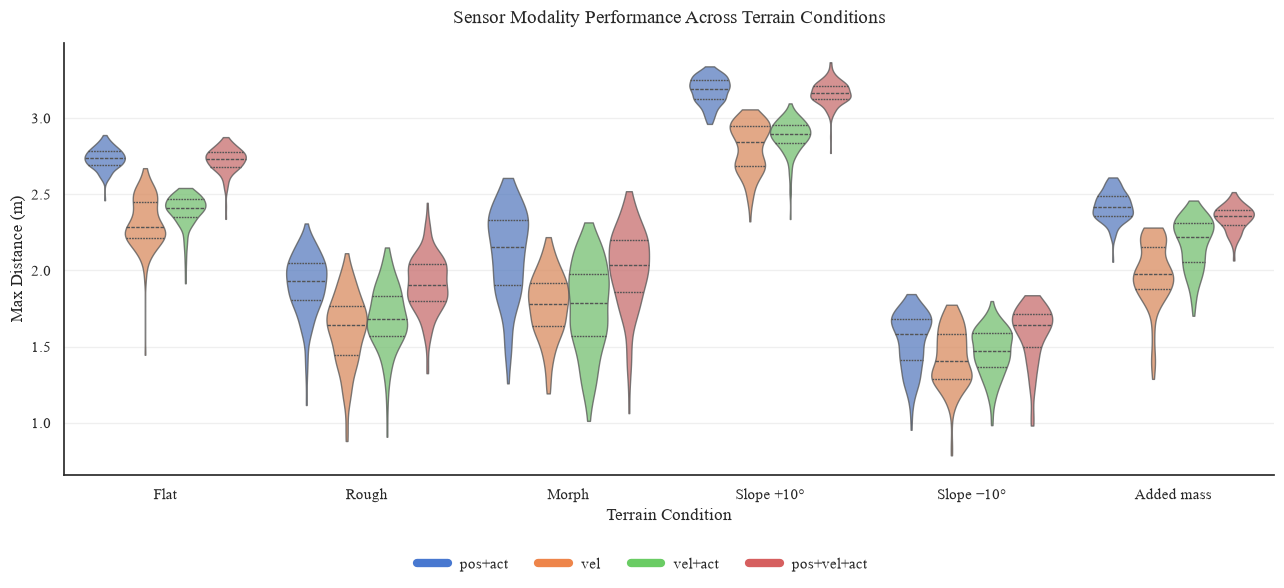

In [40]:
# ── Publication style (matches other figures in this repo) ────────────────
sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.edgecolor": "#2b2b2b",
    "grid.alpha": 0.30,
})

sensor_display_order = [SLABEL[s] for s in sensor_order]
terrain_display_order = [TLABEL[t] for t in terrain_order]

# color follows sensor identity, fixed order, consistent across every terrain
palette = dict(zip(sensor_display_order, sns.color_palette("muted", n_colors=len(sensor_order))))

fig, ax = plt.subplots(figsize=(13, 5.5))

sns.violinplot(
    data=dist_df,
    x="terrain", y="max_distance", hue="sensor",
    order=terrain_display_order, hue_order=sensor_display_order,
    palette=palette,
    inner="quartile",
    linewidth=1.0,
    cut=0,
    density_norm="width",
    ax=ax,
)

for patch in ax.collections:
    patch.set_alpha(0.75)

ax.set_xlabel("Terrain Condition", fontsize=12)
ax.set_ylabel("Max Distance (m)", fontsize=12)
ax.set_title("Sensor Modality Performance Across Terrain Conditions", fontsize=14, pad=14)
ax.get_legend().remove()

sns.despine()
fig.legend(
    handles=[plt.Line2D([0], [0], color=palette[s], lw=6) for s in sensor_display_order],
    labels=sensor_display_order,
    # title="Sensor",
    loc="lower center", ncol=len(sensor_display_order),
    frameon=False, bbox_to_anchor=(0.5, -0.08),
)
fig.tight_layout()

# fig.savefig("local_prop_max_distance_by_terrain.pdf", dpi=300, bbox_inches="tight")
fig.savefig("local_prop_max_distance_by_terrain.png", dpi=300, bbox_inches="tight")
plt.show()